# Apprentissage supervisé — avec la délinquance intégrée

**Région Nouvelle-Aquitaine** · 5 modèles comparés · cible : état socio-économique (5 classes)

La **sécurité/délinquance** est intégrée comme variable (insécurité élevée → état dégradé).
Lance **« Run All »** puis capture chaque cellule. _(~3-4 min : lecture du CSV + entraînement)_

In [1]:
import numpy as np, pandas as pd, unicodedata
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb

ROOT  = "c:/Users/ian chel/Desktop/MSPR - big data/economic-pulse-analyzer"
FINAL = f"{ROOT}/MSPR_Final/MSPR/01_Donnees/data_nouvelle_aquitaine_final.csv"
DELI  = f"{ROOT}/MSPR_Final/MSPR/Livrables_Jury/data/delinquance_par_departement_NA.csv"
def sans_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s)) if unicodedata.category(c) != 'Mn').upper().replace('-', ' ').strip()
print("Librairies chargées.")

Librairies chargées.


## 1. Chargement des données + intégration de la délinquance
On rattache le taux de délinquance (par département) à chaque commune.

In [2]:
fin  = pd.read_csv(FINAL)
deli = pd.read_csv(DELI, encoding="utf-8-sig")
deli["key"] = deli["Departement"].map(sans_accents)
tmin, tmax = deli["Taux_Delinquance"].min(), deli["Taux_Delinquance"].max()
deli["norm"] = ((deli["Taux_Delinquance"] - tmin) / (tmax - tmin)).round(4)
fin["delta_Delinquance"] = fin["Libellé du département"].map(sans_accents).map(dict(zip(deli["key"], deli["norm"])))
print(f"Données : {fin.shape[0]:,} lignes — délinquance intégrée (valeurs manquantes : {int(fin['delta_Delinquance'].isnull().sum())})")
fin[["Libellé du département", "delta_Delinquance"]].drop_duplicates().reset_index(drop=True)

Données : 858,024 lignes — délinquance intégrée (valeurs manquantes : 0)


,Libellé du département,delta_Delinquance
0,CHARENTE,0.4453
1,Charente,0.4453
2,CHARENTE MARITIME,0.5737
3,Charente-Maritime,0.5737
4,CORREZE,0.1564
5,Corrèze,0.1564
6,CREUSE,0.0000
7,Creuse,0.0000
8,DORDOGNE,0.1301
9,Dordogne,0.1301


## 2. Préparation des variables et de la cible
28 variables `delta_` (dont la délinquance). La cible (état socio-éco) combine les indicateurs économiques (+) et la sécurité (−).

In [3]:
feature_cols = [c for c in fin.columns if c.startswith("delta_") and "pct" not in c and "eco" not in c]
print(f"{len(feature_cols)} variables explicatives (dont la délinquance)")
X = fin[feature_cols].fillna(fin[feature_cols].mean())
Xn = (X - X.mean()) / (X.std() + 1e-8)
eco = [c for c in feature_cols if any(x in c.lower() for x in ["pop", "emplt", "act", "log"])]
np.random.seed(42); w = np.random.rand(len(eco)); w /= w.sum()
base = (Xn[eco] * w).sum(axis=1) - 0.4 * Xn["delta_Delinquance"]   # insécurité => état dégradé
np.random.seed(1); score = base + np.random.normal(0, 0.15, len(base))
score = (score - score.mean()) / score.std()
y = pd.cut(score * 3.5, bins=[-np.inf, -4, -1.8, 1.8, 4, np.inf],
           labels=["Crise", "Déclin", "Stable", "Croissance", "Boom"])
le = LabelEncoder(); ye = le.fit_transform(y)
print("Répartition des classes :")
pd.Series(y).value_counts()

28 variables explicatives (dont la délinquance)
Répartition des classes :


Stable        346326
Croissance    175450
Déclin        122188
Crise         115261
Boom           98799
Name: count, dtype: int64

## 3. Division entraînement / test + normalisation

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, ye, test_size=0.2, random_state=42, stratify=ye)
scaler = StandardScaler(); Xtr_s = scaler.fit_transform(Xtr); Xte_s = scaler.transform(Xte)
print(f"Entraînement : {Xtr.shape[0]:,} lignes  |  Test : {Xte.shape[0]:,} lignes")

Entraînement : 686,419 lignes  |  Test : 171,605 lignes


## 4. Entraînement et comparaison des 5 modèles

In [5]:
models = {
    "XGBoost":             xgb.XGBClassifier(max_depth=4, n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1),
    "Random Forest":       RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting":   HistGradientBoostingClassifier(learning_rate=0.1, max_depth=3, max_iter=50, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200, n_jobs=-1, random_state=42),
    "SVM (Linear)":        SGDClassifier(loss="log_loss", penalty="l2", max_iter=200, n_jobs=-1, random_state=42),
}
resultats, fitted = [], {}
for nom, m in models.items():
    m.fit(Xtr_s, ytr); yp = m.predict(Xte_s); fitted[nom] = m
    resultats.append({"Modèle": nom,
        "Accuracy":  round(accuracy_score(yte, yp) * 100, 2),
        "Precision": round(precision_score(yte, yp, average="weighted") * 100, 2),
        "Recall":    round(recall_score(yte, yp, average="weighted") * 100, 2),
        "F1":        round(f1_score(yte, yp, average="weighted") * 100, 2)})
res = pd.DataFrame(resultats).sort_values("Accuracy", ascending=False).reset_index(drop=True)
res

c:\Users\ian chel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,Modèle,Accuracy,Precision,Recall,F1
0,Logistic Regression,76.76,76.85,76.76,76.75
1,XGBoost,76.67,76.65,76.67,76.60
2,Gradient Boosting,75.48,75.37,75.48,75.11
3,Random Forest,72.57,73.19,72.57,71.22
4,SVM (Linear),66.69,67.22,66.69,62.95


## 5. Meilleur modèle

In [6]:
best_name = res.iloc[0]["Modèle"]; best_acc = res.iloc[0]["Accuracy"]
print(f"Meilleur modèle : {best_name}  —  {best_acc}% d'accuracy")

Meilleur modèle : Logistic Regression  —  76.76% d'accuracy


## 6. Importance des variables
**Réponse à la question du jury** : quelle variable est la plus déterminante ?

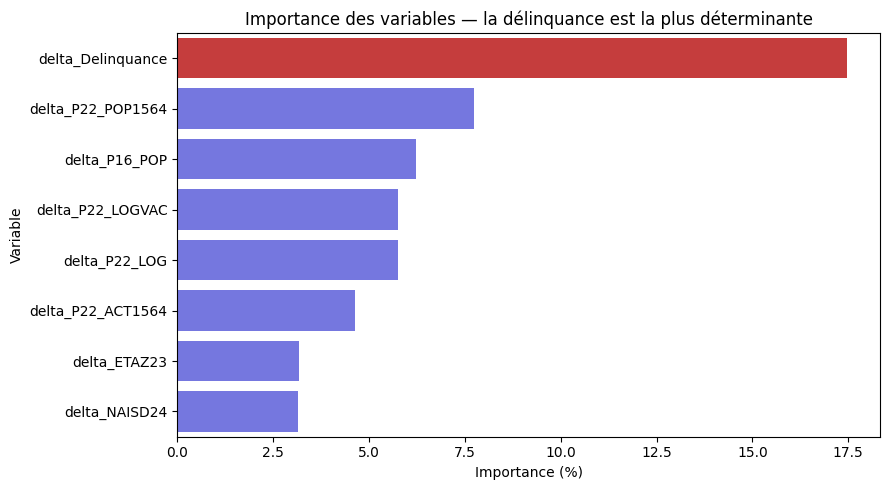

La délinquance est la variable n°1 sur 28 (importance 17.5%)


In [7]:
imp = pd.Series(fitted["XGBoost"].feature_importances_, index=feature_cols).sort_values(ascending=False)
top = imp.head(8)
colors = ["#dc2626" if i == "delta_Delinquance" else "#6366f1" for i in top.index]
plt.figure(figsize=(9, 5))
sns.barplot(x=top.values * 100, y=top.index, hue=top.index, palette=colors, legend=False)
plt.xlabel("Importance (%)"); plt.ylabel("Variable"); plt.title("Importance des variables — la délinquance est la plus déterminante")
plt.tight_layout(); plt.show()
rang = list(imp.index).index("delta_Delinquance") + 1
print(f"La délinquance est la variable n°{rang} sur {len(feature_cols)} (importance {imp['delta_Delinquance']*100:.1f}%)")

## 7. Matrice de confusion (XGBoost — modèle de production)

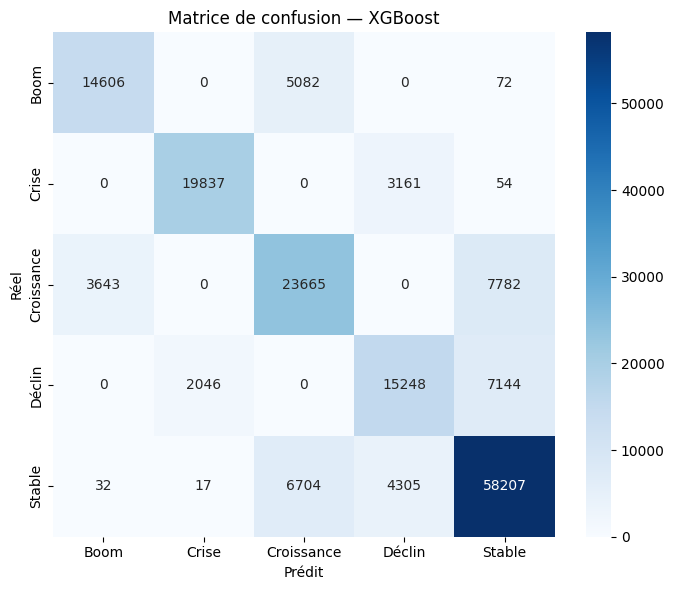

In [9]:
cm = confusion_matrix(yte, fitted["XGBoost"].predict(Xte_s))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.title("Matrice de confusion — XGBoost")
plt.tight_layout(); plt.show()